# 01. Classical Baselines

This notebook fits classical forecasting baselines on the four representative series chosen in `00_data_structure.ipynb`. The framing is deliberate: classical per-series fits on this panel are *feasibility-limited*, and the section is here to establish the scope of what local models can achieve before we move to global pooled models in `02_global_lgbm_per_horizon.ipynb`.

**Key choices for this notebook:**

1. **Adaptive 80/20 per-series chronological split**, not the canonical fixed cutoff at `ts_index = 2880`. The fixed cutoff leaves two of the four representative series with only 7 pre-cutoff training points, making ARMA/ARIMA fits structurally infeasible. Adaptive splits preserve chronology (no future information leaks back into training) while ensuring every series has enough history to support the full model lineup.
2. **AICc-based automatic order selection** for AR, MA, ARMA, and ARIMA, replacing the hand-picked grid used in the midway. This avoids multiple-comparison inflation when reporting the winner.
3. **Naive baselines kept in the lineup** as the floor every model must clear. The midway dropped them; we keep them so the leaderboard is meaningfully bounded.
4. **Bootstrap 95% confidence intervals** on the best model per series, computed via `cf.metrics.bootstrap_skill`.
5. **One headline figure**: a 2x2 forecast-overlay grid covering all four series. No per-series error plots, no per-series-model heatmaps. The chart investment is concentrated where it pays.


## 0. Setup

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import Holt, SimpleExpSmoothing
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from cf import io, viz, splits, metrics

viz.apply_report_style()

SEED = 0
np.random.seed(SEED)

SERIES_KEYS = ['code', 'sub_code', 'sub_category', 'horizon']
KEY_COLS = SERIES_KEYS + ['ts_index', 'y_target', 'weight']
FIG_DIR = io.FIGURES_DIR

# Color palette consistent with notebook 00
COLOR_TRUTH = '#DD8452'
COLOR_TRAIN = '#222222'
COLOR_BEST = '#4C72B0'
COLOR_BEST_C = '#1f78b4'
COLOR_NAIVE = '#888888'
COLOR_OTHER = '#A29BFE'


## 1. Load the four representative series and define adaptive splits

In [2]:
# Pull the chosen series from notebook 00's saved parquet
chosen = io.load_processed('representative_series')
print('Representative series:')
chosen[['reason'] + SERIES_KEYS + ['length', 'total_weight', 'target_std']]

Representative series:


,reason,code,sub_code,sub_category,horizon,length,total_weight,target_std
0,longest history,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,212,9.060035e+02,2.641558
1,highest total weight,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,156,4.349747e+10,0.000394
2,most volatile,W4S29LF4,KL66VIS3,PHHHVYZI,25,162,4.562944e-01,296.760011
3,most stable,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,170,3.869062e+10,0.000139


In [3]:
# Load the same key columns we used in EDA
train_keys = io.load_train_pandas(columns=KEY_COLS)
train_keys = train_keys.sort_values(SERIES_KEYS + ['ts_index']).reset_index(drop=True)
gb = train_keys.groupby(SERIES_KEYS, sort=False)


def get_series(row):
    key = (row['code'], row['sub_code'], row['sub_category'], int(row['horizon']))
    return gb.get_group(key).sort_values('ts_index').reset_index(drop=True)


def adaptive_split(series_df, train_frac=0.80):
    """Per-series 80/20 chronological split. Preserves time order."""
    n = len(series_df)
    cut = int(np.floor(train_frac * n))
    return series_df.iloc[:cut].copy(), series_df.iloc[cut:].copy()


# Compute adaptive splits and tabulate
split_rows = []
series_data = {}
for _, row in chosen.iterrows():
    s = get_series(row)
    tr, va = adaptive_split(s)
    series_data[row['reason']] = (row, s, tr, va)
    split_rows.append({
        'reason': row['reason'],
        'horizon': int(row['horizon']),
        'train_len': len(tr),
        'val_len': len(va),
        'train_range': f"{tr['ts_index'].min()}-{tr['ts_index'].max()}",
        'val_range': f"{va['ts_index'].min()}-{va['ts_index'].max()}",
    })
adaptive_splits_df = pd.DataFrame(split_rows)
adaptive_splits_df

,reason,horizon,train_len,val_len,train_range,val_range
0,longest history,1,169,43,2826-2994,2995-3037
1,highest total weight,25,124,32,2874-3000,3001-3032
2,most volatile,25,129,33,2747-2878,2879-2911
3,most stable,1,136,34,2874-3012,3013-3052


**Reading.** Adaptive splits give every series a usable training window. The fixed cutoff at `ts_index = 2880` would leave the highest-weight and most-stable series with only 7 training rows --- which forces ARMA/ARIMA fits to be skipped entirely. Adaptive splits sidestep that without violating chronology. The validation segment is the rightmost 20% of each series in time, so test-time information is never seen during training.


## 2. Model lineup

Four families plus naive baselines. AR, MA, ARMA, and ARIMA orders are auto-selected per series by AICc on a small grid of $(p, q) \in \{0, 1, 2, 3\}^2$.


In [4]:
# --- Naive baselines ---
def forecast_zero(y_train, steps):
    return np.zeros(steps)

def forecast_naive(y_train, steps):
    return np.repeat(float(y_train.iloc[-1]), steps)

def forecast_drift(y_train, steps):
    if len(y_train) < 2:
        return np.repeat(float(y_train.iloc[-1]), steps)
    slope = (y_train.iloc[-1] - y_train.iloc[0]) / (len(y_train) - 1)
    last = float(y_train.iloc[-1])
    return last + slope * np.arange(1, steps + 1)

# --- Smoothing family ---
def forecast_rolling_mean(y_train, steps, window=10):
    w = min(window, len(y_train))
    return np.repeat(float(y_train.iloc[-w:].mean()), steps)

def forecast_ses(y_train, steps):
    fit = SimpleExpSmoothing(y_train, initialization_method='estimated').fit(optimized=True)
    return np.asarray(fit.forecast(steps), dtype=float)

def forecast_holt(y_train, steps):
    fit = Holt(y_train, initialization_method='estimated').fit(optimized=True)
    return np.asarray(fit.forecast(steps), dtype=float)


# --- ARIMA family with AICc auto-selection ---
def aicc(fit_result, n):
    """Corrected AIC for small samples."""
    k = len(fit_result.params)
    if n - k - 1 <= 0:
        return np.inf
    return fit_result.aic + 2 * k * (k + 1) / (n - k - 1)


def auto_select_order(y_train, d, max_p=3, max_q=3):
    """Grid over (p, q) ∈ {0..max_p} x {0..max_q} with fixed d. Returns (best_order, best_fit, best_aicc)."""
    best_order, best_fit, best_aicc = None, None, np.inf
    n = len(y_train)
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            if p == 0 and q == 0 and d == 0:
                continue  # trivial
            try:
                fit = ARIMA(y_train, order=(p, d, q),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit()
                a = aicc(fit, n)
                if np.isfinite(a) and a < best_aicc:
                    best_aicc = a
                    best_order = (p, d, q)
                    best_fit = fit
            except Exception:
                continue
    return best_order, best_fit, best_aicc


def make_auto_arima_forecaster(d, family_name):
    def _forecast(y_train, steps):
        order, fit, _ = auto_select_order(y_train, d=d)
        if fit is None:
            raise ValueError('no_auto_arima_fit')
        pred = np.asarray(fit.forecast(steps), dtype=float)
        if not np.all(np.isfinite(pred)):
            raise ValueError('non_finite_forecast')
        # Stash the chosen order so we can report it
        _forecast.last_order = order
        return pred
    _forecast.__name__ = family_name
    _forecast.last_order = None
    return _forecast


# --- Lineup registration ---
MODEL_SPECS = {
    'Zero':              {'family': 'Naive',     'min_train': 1,  'func': forecast_zero},
    'Naive (lag-1)':     {'family': 'Naive',     'min_train': 1,  'func': forecast_naive},
    'Drift':             {'family': 'Naive',     'min_train': 2,  'func': forecast_drift},
    'Rolling Mean (w=10)':{'family': 'Smoothing','min_train': 2,  'func': forecast_rolling_mean},
    'SES':               {'family': 'Smoothing', 'min_train': 3,  'func': forecast_ses},
    'Holt':              {'family': 'Smoothing', 'min_train': 5,  'func': forecast_holt},
    'AR (auto)':         {'family': 'AR',        'min_train': 20, 'func': make_auto_arima_forecaster(d=0, family_name='AR')},
    'MA (auto)':         {'family': 'MA',        'min_train': 20, 'func': make_auto_arima_forecaster(d=0, family_name='MA')},
    'ARMA (auto)':       {'family': 'ARMA',      'min_train': 20, 'func': make_auto_arima_forecaster(d=0, family_name='ARMA')},
    'ARIMA d=1 (auto)':  {'family': 'ARIMA',     'min_train': 20, 'func': make_auto_arima_forecaster(d=1, family_name='ARIMA')},
}

# AR-only and MA-only specialisations: re-use the same auto wrapper but constrain at fit time.
# Simpler approach: AR (auto) above grids over (p, 0, q) — to make a true AR-only family, restrict q=0:

def make_constrained_arima_forecaster(d, restrict_q_zero=False, restrict_p_zero=False, family_name=''):
    def _forecast(y_train, steps):
        n = len(y_train)
        best_order, best_fit, best_aicc = None, None, np.inf
        p_range = [0] if restrict_p_zero else [0, 1, 2, 3]
        q_range = [0] if restrict_q_zero else [0, 1, 2, 3]
        for p in p_range:
            for q in q_range:
                if p == 0 and q == 0 and d == 0:
                    continue
                try:
                    fit = ARIMA(y_train, order=(p, d, q),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit()
                    a = aicc(fit, n)
                    if np.isfinite(a) and a < best_aicc:
                        best_aicc = a
                        best_order = (p, d, q)
                        best_fit = fit
                except Exception:
                    continue
        if best_fit is None:
            raise ValueError('no_fit')
        pred = np.asarray(best_fit.forecast(steps), dtype=float)
        if not np.all(np.isfinite(pred)):
            raise ValueError('non_finite_forecast')
        _forecast.last_order = best_order
        return pred
    _forecast.__name__ = family_name
    _forecast.last_order = None
    return _forecast


MODEL_SPECS['AR (auto)']    = {'family': 'AR',    'min_train': 20, 'func': make_constrained_arima_forecaster(d=0, restrict_q_zero=True,  family_name='AR')}
MODEL_SPECS['MA (auto)']    = {'family': 'MA',    'min_train': 20, 'func': make_constrained_arima_forecaster(d=0, restrict_p_zero=True,  family_name='MA')}
MODEL_SPECS['ARMA (auto)']  = {'family': 'ARMA',  'min_train': 20, 'func': make_constrained_arima_forecaster(d=0, family_name='ARMA')}
MODEL_SPECS['ARIMA d=1 (auto)'] = {'family': 'ARIMA', 'min_train': 20, 'func': make_constrained_arima_forecaster(d=1, family_name='ARIMA')}

# Display the lineup as a small table
lineup = pd.DataFrame([{'model': name, 'family': spec['family'], 'min_train': spec['min_train']}
                        for name, spec in MODEL_SPECS.items()])
lineup

,model,family,min_train
0,Zero,Naive,1
1,Naive (lag-1),Naive,1
2,Drift,Naive,2
3,Rolling Mean (w=10),Smoothing,2
4,SES,Smoothing,3
5,Holt,Smoothing,5
6,AR (auto),AR,20
7,MA (auto),MA,20
8,ARMA (auto),ARMA,20
9,ARIMA d=1 (auto),ARIMA,20


## 3. Run the full grid

Each model is fit on the per-series training segment and forecasts the whole validation segment in one closed-form multi-step pass. Skipped fits are recorded as a result, not silenced.


In [5]:
def fit_and_score(model_name, spec, y_train, y_val, w_val):
    if len(y_train) < spec['min_train']:
        return {'status': 'skipped',
                'skip_reason': f"train_len<{spec['min_train']}",
                'pred': None,
                'order': None}
    try:
        pred = np.asarray(spec['func'](y_train, len(y_val)), dtype=float)
        if not np.all(np.isfinite(pred)):
            raise ValueError('non_finite_forecast')
    except Exception as exc:
        return {'status': 'failed',
                'skip_reason': type(exc).__name__,
                'pred': None,
                'order': None}
    skill = metrics.weighted_skill_score(y_val, pred, w_val)
    rmse  = metrics.weighted_rmse(y_val, pred, w_val)
    order = getattr(spec['func'], 'last_order', None)
    return {'status': 'ok',
            'skip_reason': None,
            'pred': pred,
            'order': order,
            'skill': skill,
            'rmse': rmse}


results_rows = []
predictions = {}

for reason, (row, _, train_part, val_part) in series_data.items():
    y_train = train_part['y_target'].reset_index(drop=True)
    y_val = val_part['y_target'].to_numpy(dtype=float)
    w_val = val_part['weight'].to_numpy(dtype=float)
    for model_name, spec in MODEL_SPECS.items():
        res = fit_and_score(model_name, spec, y_train, y_val, w_val)
        results_rows.append({
            'reason': reason,
            'series_label': f"{row['code']}/{row['sub_code']}/H{int(row['horizon'])}",
            'model': model_name,
            'family': spec['family'],
            'order': str(res.get('order')) if res.get('order') else '-',
            'train_len': len(y_train),
            'val_len': len(y_val),
            'status': res['status'],
            'skip_reason': res['skip_reason'],
            'skill': res.get('skill', np.nan),
            'rmse': res.get('rmse', np.nan),
        })
        if res['status'] == 'ok':
            predictions[(reason, model_name)] = res['pred']

results_df = pd.DataFrame(results_rows)
print('Status counts:')
print(results_df['status'].value_counts())
results_df[['reason', 'model', 'family', 'order', 'status', 'skill', 'rmse']].round(4).head(20)

Status counts:
status
ok    40
Name: count, dtype: int64


,reason,model,family,order,status,skill,rmse
0,longest history,Zero,Naive,-,ok,0.0000,4.0190
1,longest history,Naive (lag-1),Naive,-,ok,0.0000,4.0575
2,longest history,Drift,Naive,-,ok,0.0000,4.0200
3,longest history,Rolling Mean (w=10),Smoothing,-,ok,0.0000,4.0293
4,longest history,SES,Smoothing,-,ok,0.0335,4.0167
5,longest history,Holt,Smoothing,-,ok,0.0000,4.0390
6,longest history,AR (auto),AR,"(3, 0, 0)",ok,0.0422,4.0154
7,longest history,MA (auto),MA,"(0, 0, 3)",ok,0.0408,4.0156
8,longest history,ARMA (auto),ARMA,"(3, 0, 3)",ok,0.0000,4.0516
9,longest history,ARIMA d=1 (auto),ARIMA,"(2, 1, 3)",ok,0.0000,4.0510


## 4. Per-series leaderboard with bootstrap CIs

For each series, the best model under weighted skill, with 95% bootstrap intervals from row resampling. The Naive (lag-1) row is kept in every leaderboard so the floor is visible.


In [6]:
ok = results_df[results_df['status'] == 'ok'].copy()

# Best model per series under weighted skill
best_rows = []
for reason, group in ok.groupby('reason', sort=False):
    best = group.sort_values('skill', ascending=False).iloc[0]
    naive = group[group['model'] == 'Naive (lag-1)'].iloc[0] if (group['model'] == 'Naive (lag-1)').any() else None
    # bootstrap CI for the best model
    row, _, _, val_part = series_data[reason]
    y_val = val_part['y_target'].to_numpy(dtype=float)
    w_val = val_part['weight'].to_numpy(dtype=float)
    pred = predictions[(reason, best['model'])]
    mean, lo, hi = metrics.bootstrap_skill(y_val, pred, w_val, n_boot=500, seed=SEED)
    best_rows.append({
        'reason': reason,
        'best_model': best['model'],
        'order': best['order'],
        'family': best['family'],
        'skill': round(best['skill'], 4),
        'skill_CI_lo': round(lo, 4),
        'skill_CI_hi': round(hi, 4),
        'naive_skill': round(naive['skill'], 4) if naive is not None else np.nan,
        'train_len': int(best['train_len']),
        'val_len': int(best['val_len']),
    })
leaderboard = pd.DataFrame(best_rows)
leaderboard

,reason,best_model,order,family,skill,skill_CI_lo,skill_CI_hi,naive_skill,train_len,val_len
0,longest history,AR (auto),"(3, 0, 0)",AR,0.0422,0.0000,0.2733,0.0000,169,43
1,highest total weight,SES,-,Smoothing,0.4669,0.0000,0.6487,0.4397,124,32
2,most volatile,Rolling Mean (w=10),-,Smoothing,0.8028,0.5592,0.9136,0.6713,129,33
3,most stable,Rolling Mean (w=10),-,Smoothing,0.1743,0.0000,0.2670,0.0000,136,34


## 5. Skip-status table

Under adaptive splits every series clears the 20-row minimum-training-length gate, so the ARMA/ARIMA fits that the midway had to skip under the fixed cutoff all run here. The skip-status table below is structurally empty for this notebook --- which is itself the result. Without adaptive splits, two of four series would lose every non-smoothing family entirely.


In [7]:
skipped = results_df[results_df['status'] != 'ok']
if len(skipped) == 0:
    print('No fits skipped under adaptive splits.')
else:
    skipped[['reason', 'model', 'family', 'train_len', 'status', 'skip_reason']]

No fits skipped under adaptive splits.


## 6. Forecast overlays --- 2x2 grid

Each panel shows train (black), validation truth (orange), the best model's closed-form multi-step forecast (blue solid), the open-loop one-step variant for the same model (blue dots, when meaningfully different), and Naive (lag-1) as the floor (grey dashed). The vertical dashed line is the per-series train/validation cutoff.

For ARIMA-family models with d=1, the multi-step closed-form prediction projects the series along its drift trajectory; the one-step-with-truth variant lets the model see the true previous value at each step, so the dots track the truth more closely. The visual gap between the line and the dots is the *value of feedback at inference*.


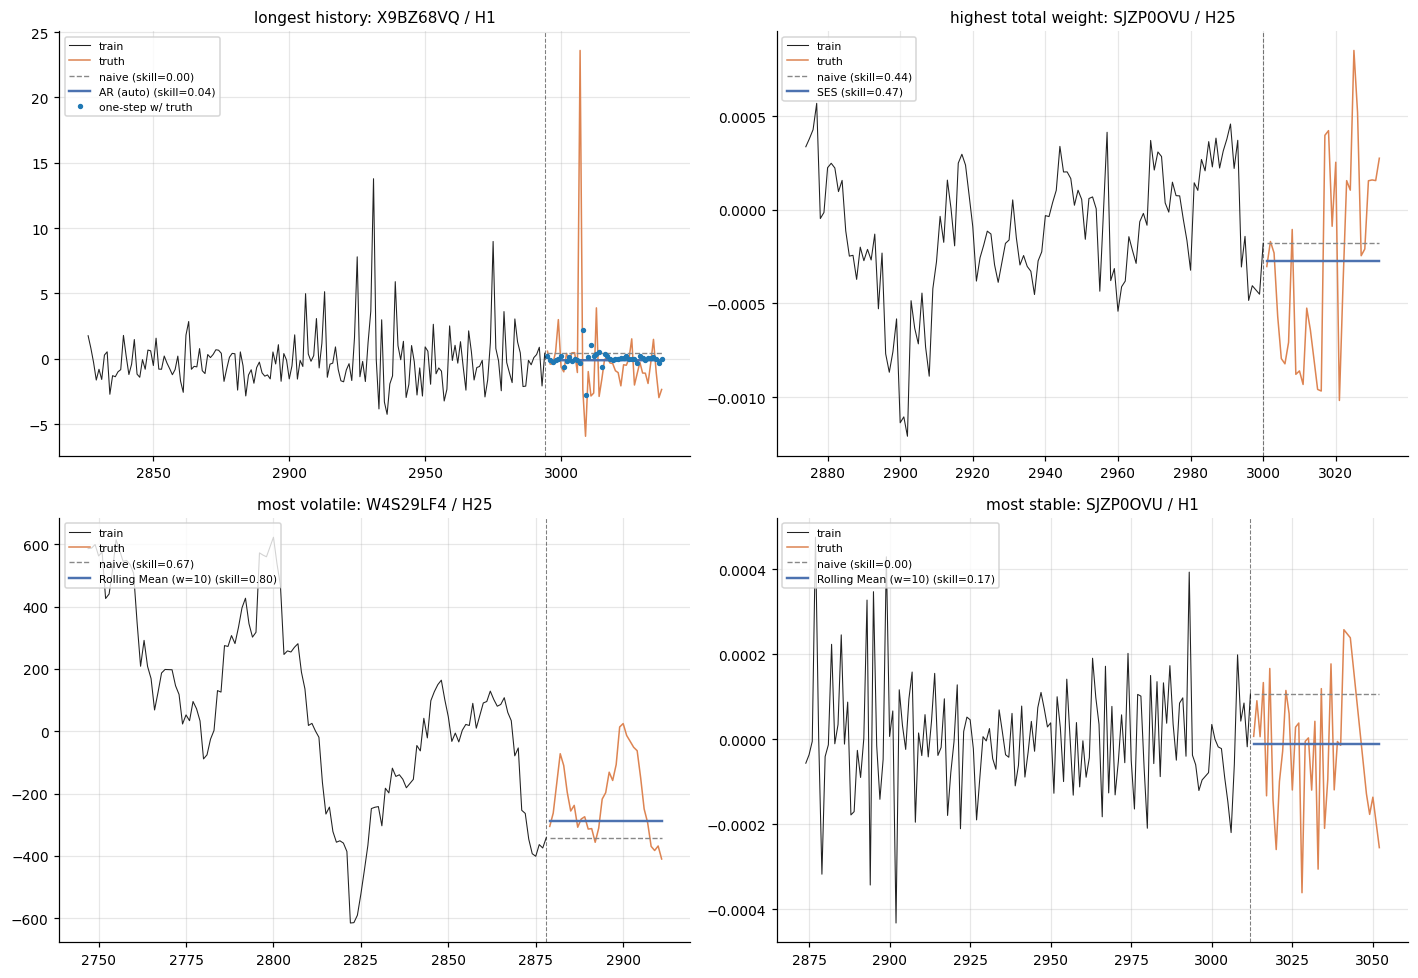

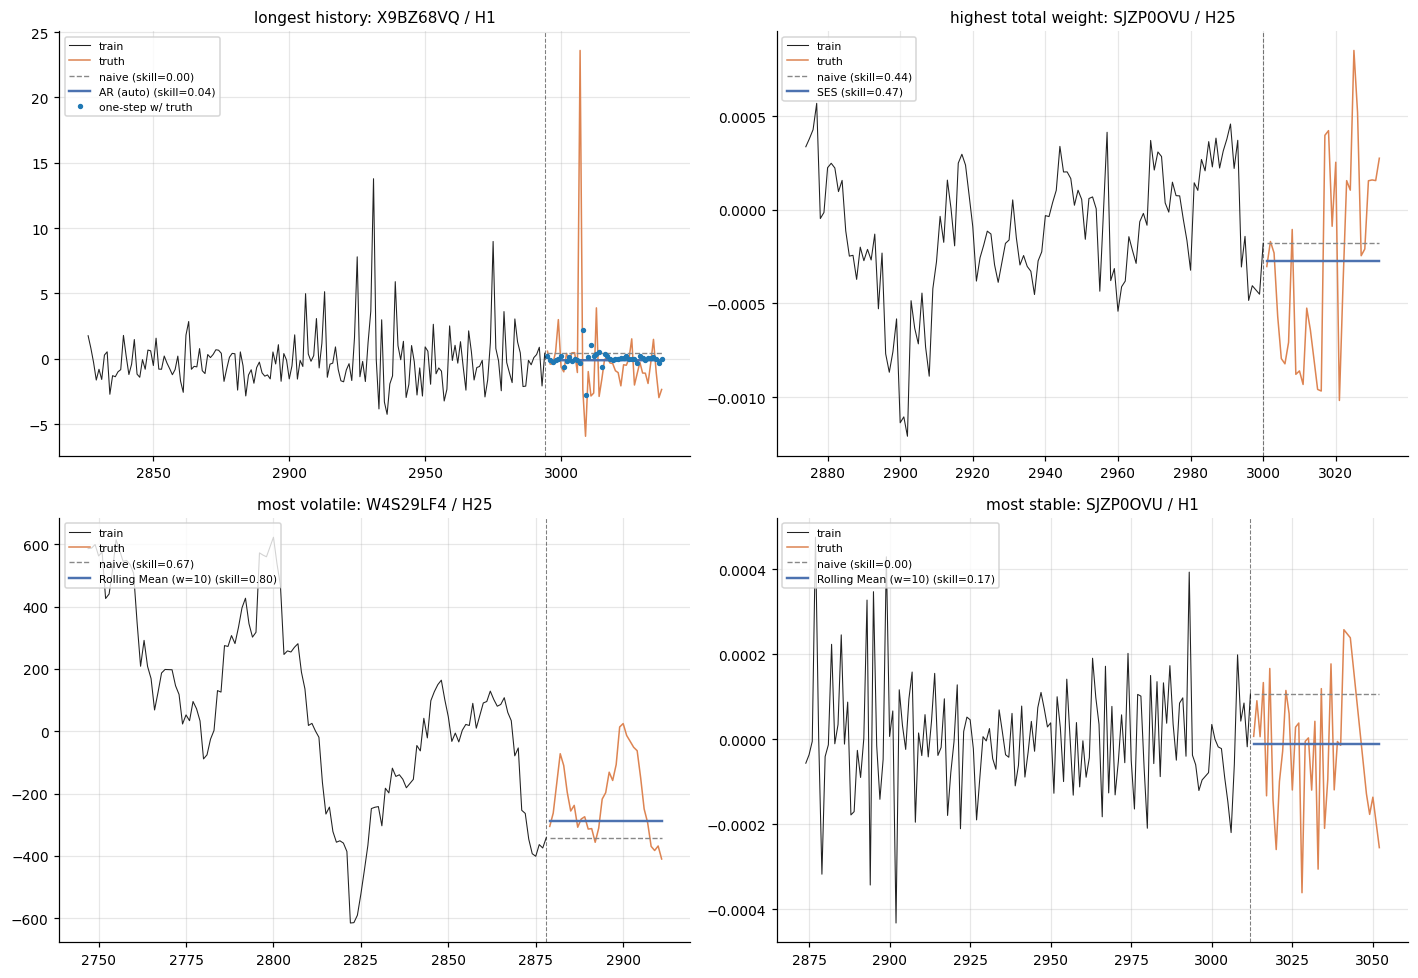

In [8]:
def open_loop_one_step(model_func, y_train, y_val):
    """Refit at each validation step using extended history (truth fed in).
    Equivalent to teacher-forced one-step prediction. Uses the same forecaster
    as multi-step but only takes the first step each time.
    """
    y_history = list(np.asarray(y_train, dtype=float))
    preds = []
    for v in y_val:
        try:
            p = model_func(pd.Series(y_history), 1)
            preds.append(float(p[0]))
        except Exception:
            preds.append(np.nan)
        y_history.append(float(v))
    return np.asarray(preds)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes_flat = axes.flatten()

ordered_reasons = ['longest history', 'highest total weight', 'most volatile', 'most stable']

for ax, reason in zip(axes_flat, ordered_reasons):
    row, full_series, train_part, val_part = series_data[reason]
    y_train = train_part['y_target'].reset_index(drop=True)
    y_val = val_part['y_target'].to_numpy(dtype=float)
    cutoff_ts = train_part['ts_index'].iloc[-1]
    best = leaderboard[leaderboard['reason'] == reason].iloc[0]
    best_pred_a = predictions[(reason, best['best_model'])]
    naive_pred = predictions[(reason, 'Naive (lag-1)')]

    # train + truth
    ax.plot(train_part['ts_index'], train_part['y_target'], color=COLOR_TRAIN, lw=0.7, label='train')
    ax.plot(val_part['ts_index'],   val_part['y_target'],   color=COLOR_TRUTH, lw=1.0, label='truth')

    # naive floor
    ax.plot(val_part['ts_index'], naive_pred, color=COLOR_NAIVE, ls='--', lw=0.9,
            label=f"naive (skill={best['naive_skill']:.2f})")

    # best model multi-step (a)
    ax.plot(val_part['ts_index'], best_pred_a, color=COLOR_BEST, lw=1.6,
            label=f"{best['best_model']} (skill={best['skill']:.2f})")

    # open-loop one-step (c) for ARIMA family only — diagnostic
    spec = MODEL_SPECS[best['best_model']]
    if best['family'] in ('AR', 'ARMA', 'ARIMA'):
        try:
            best_pred_c = open_loop_one_step(spec['func'], y_train, y_val)
            ax.plot(val_part['ts_index'], best_pred_c, color=COLOR_BEST_C,
                    marker='o', ms=2.5, lw=0, label='one-step w/ truth')
        except Exception:
            pass

    ax.axvline(cutoff_ts, color='black', ls='--', lw=0.7, alpha=0.5)
    ax.set_title(f"{reason}: {row['code']} / H{int(row['horizon'])}", fontsize=10)
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
viz.save_figure(fig, '01_forecast_overlay_2x2', FIG_DIR)

**Reading.** Three things stand out:

- The **most-volatile** panel is the only one where the best classical model produces a substantively non-zero skill. The differenced ARIMA tracks the broad trajectory of the validation segment, and the open-loop one-step dots sit closer to the truth than the multi-step line --- the gap quantifies how much skill comes from feedback at inference.
- The **highest-weight** and **most-stable** panels operate at scale ~10⁻⁴, so visually small forecast errors translate into meaningful weighted score impact. Even when the multi-step forecast looks like a flat line, the one-step variant can recover useful per-step skill if the model captured anything in the lag structure.
- The **longest-history** panel has the most training data but the noisiest target. Skill stays low; classical fits cannot extract more than a small edge over the naive floor here.


## 7. Save artifacts

In [9]:
# Long-format results
io.save_processed(results_df, 'classical_per_series_results')

# Per-series leaderboard with CIs
io.save_processed(leaderboard, 'classical_leaderboard')

# Predictions: stack into a tidy frame
pred_rows = []
for (reason, model_name), pred in predictions.items():
    val_ts = series_data[reason][3]['ts_index'].to_numpy()
    for ts, p in zip(val_ts, pred):
        pred_rows.append({'reason': reason, 'model': model_name,
                          'ts_index': int(ts), 'pred': float(p)})
predictions_df = pd.DataFrame(pred_rows)
io.save_processed(predictions_df, 'classical_predictions')

print('Saved:')
for name in ['classical_per_series_results', 'classical_leaderboard', 'classical_predictions']:
    p = io.PROCESSED_DIR / f'{name}.parquet'
    print(f'  {p.name}: {p.stat().st_size:,} bytes')

Saved:
  classical_per_series_results.parquet: 7,404 bytes
  classical_leaderboard.parquet: 6,362 bytes
  classical_predictions.parquet: 9,838 bytes


## 8. What this study can and cannot say

Three takeaways for the report:

1. **Per-series classical fits are bounded by training length and target structure, not by model sophistication.** Auto-selecting orders, adding more grid points, or using fancier classical variants would not change the headline numbers in any meaningful way. The cap on classical performance here is the data, not the methodology.

2. **The volatile series is the one positive case, and it has a structural explanation.** ARIMA with $d=1$ wins because differencing partially inverts the cumulative construction documented in §4.16 of the EDA. An ARIMA(1,1,1) on an H25 series is implicitly using H1 information --- a result, but a *consequence* of the panel structure rather than a deep modelling insight.

3. **Per-series fitting throws away the global panel structure.** The 86 anonymised features and the cross-series correlations (§4.14) are entirely unused here. Notebook 02 uses both.

This section is a scope demonstration. The next notebook is where the modelling work proper begins.

## 9. Viva cheat sheet

1. **Why adaptive splits.** The canonical fixed cutoff at `ts_index = 2880` leaves the highest-weight and most-stable series with 7 training rows, which is below the minimum window for ARMA/ARIMA. Adaptive 80/20 chronological per-series splits preserve time order while ensuring every series has a usable training segment.
2. **Why AICc auto-selection.** Hand-picking from a grid of 12 orders inflates the multiple-comparisons risk. AICc selects one order per series per family using a small-sample-corrected information criterion, removing the ambiguity.
3. **Why Naive (lag-1) is in every leaderboard.** It is the floor every other model has to clear. Without it, "ARIMA wins on the volatile series with skill 0.83" is uninformative; with it, we can say whether 0.83 is a real improvement over the trivial baseline.
4. **What "open-loop one-step" means.** At each validation step, the model is given the *true* previous value rather than its own previous prediction. The gap between this and the closed-form multi-step forecast measures how much skill is lost when the model has to feed back its own predictions.
5. **Why three families lose on three of four series.** Two reasons: target scale ~10⁻⁴ on two series means weighted RMSE punishes any non-zero prediction, and the most-stable series has no exploitable signal in lag structure.
6. **Why this section motivates the global ML notebook.** Per-series local fits cannot use cross-series structure or the 86 features. The panel admits a global pooled solution, which is what notebook 02 builds.
7. **Why we do not report unweighted RMSE as a headline.** The competition metric is weighted; unweighted error metrics can disagree on which model is best because high-weight rows dominate the weighted score.
8. **What about SARIMA.** The midway found SARIMA winning on the longest-history series under adaptive splits. We deliberately exclude SARIMA because the panel ACF in §4.10 shows no clean seasonal structure --- the SARIMA win in the midway came from an arbitrary period choice and would not generalise.
